In [2]:
import itertools
import math
import time
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

df1 = pd.read_csv("../PNN_round2_TuRBO/pairing_results_round2_data1.csv")

column_names  = ['NP1', 'NP2', 'NP3', 'NP4','NP5', 'NP6', 'NP7', 'NP8','NP9', 'NP10']
hf1 = pd.read_csv("../PNN_round2_TuRBO/heatflux_all_round2_data1.csv",header=None, names=column_names)
hf2 = pd.read_csv("../PNN_round2_TuRBO/heatflux_all_round2_data2.csv",header=None, names=column_names)
hf3 = pd.read_csv("../PNN_round2_TuRBO/heatflux_all_round2_data3.csv",header=None, names=column_names)
hf4 = pd.read_csv("../PNN_round2_TuRBO/heatflux_all_round2_data4.csv",header=None, names=column_names)
hf5 = pd.read_csv("../PNN_round2_TuRBO/heatflux_all_round2_data5.csv",header=None, names=column_names)
hf6 = pd.read_csv("../PNN_round2_TuRBO/heatflux_all_round2_data6.csv",header=None, names=column_names)



      T3     T4     T5     T6     T7     T8     T9    T10     k1     k2  ...  \
0  0.432  0.511  0.238  0.445  0.315  0.077  0.761  0.855  0.676  0.388  ...   
1  0.747  0.359  0.833  0.048  0.283  0.422  0.746  0.629  0.729  0.153  ...   
2  0.409  0.459  0.864  0.536  0.278  0.153  0.876  0.926  0.281  0.374  ...   
3  0.842  0.440  0.524  0.503  0.327  0.096  0.123  0.841  0.430  0.197  ...   
4  0.561  0.246  0.688  0.240  0.272  0.425  0.831  0.546  0.639  0.160  ...   

     k11    k12    k13    k14    k15    k16    k17    k18    k19    k20  
0  0.859  0.103  0.268  0.175  0.095  0.336  0.338  0.105  0.419  0.273  
1  0.479  0.001  0.152  0.228  0.215  0.318  0.056  0.278  0.845  0.314  
2  0.329  0.387  0.064  0.241  0.007  0.078  0.382  0.171  0.320  0.143  
3  0.787  0.444  0.112  0.057  0.320  0.034  0.099  0.284  0.272  0.602  
4  0.492  0.166  0.200  0.030  0.092  0.281  0.155  0.318  0.280  0.255  

[5 rows x 28 columns]


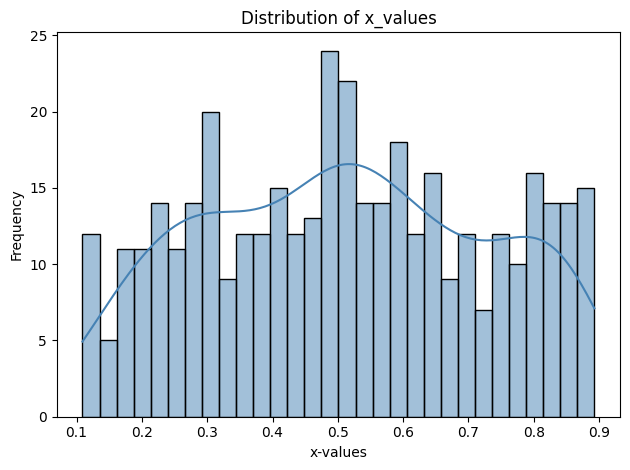

In [3]:
x_values = df1.iloc[:, 4:33]
# Apply the transformation only to the first column in x_values
x_values["T3"] = (1 + (250 - df1["T3"]) / 5)/2
x_values["T4"] = (1 + (250 - df1["T4"]) / 5)/2
x_values["T5"] = (1 + (250 - df1["T5"]) / 5)/2
x_values["T6"] = (1 + (250 - df1["T6"]) / 5)/2
x_values["T7"] = (1 + (200 - df1["T7"]) / 5)/2
x_values["T8"] = (1 + (200 - df1["T8"]) / 5)/2
x_values["T9"] = (1 + (150 - df1["T9"]) / 5)/2
x_values["T10"] = (1 + (150 - df1["T10"]) / 5)/2
for i in range(1, 21):
    col = f'k{i}'
    x_values[col] = df1[col] / 9

print(x_values.head())

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the first column
sns.histplot(x_values["T5"], kde=True, bins=30, color='steelblue')

plt.title(f"Distribution of x_values")
plt.xlabel("x-values")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Write to CSV file
import csv

x_values_rounded = x_values.round(3)

with open("round2_x_values.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(x_values_rounded.columns)          # write header
    writer.writerows(x_values_rounded.to_numpy())      # write data rows


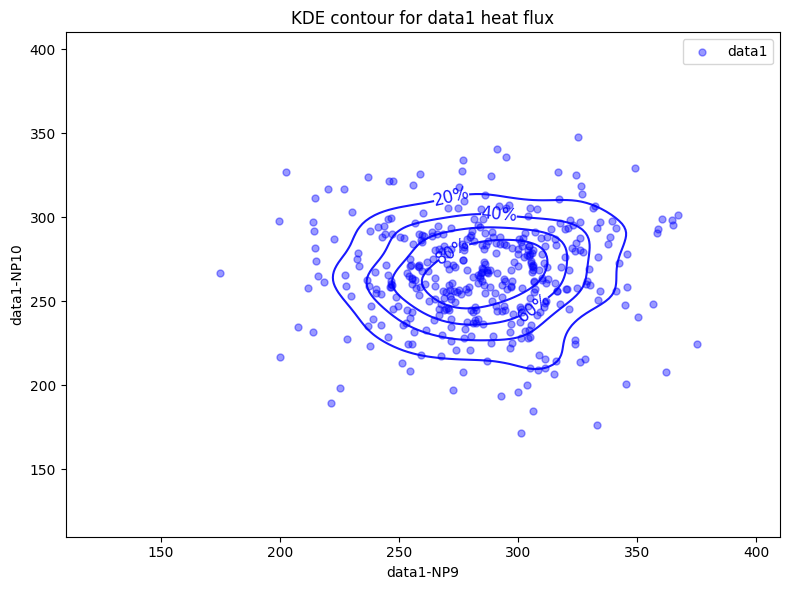

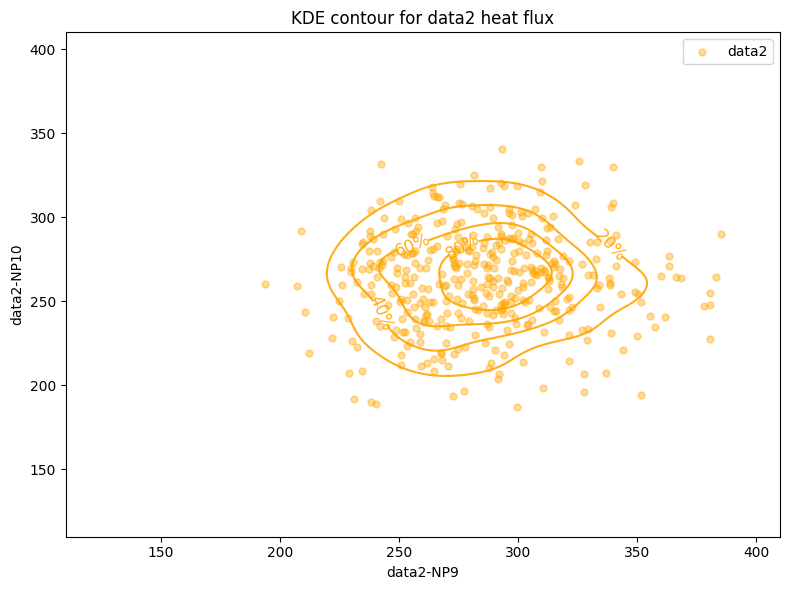

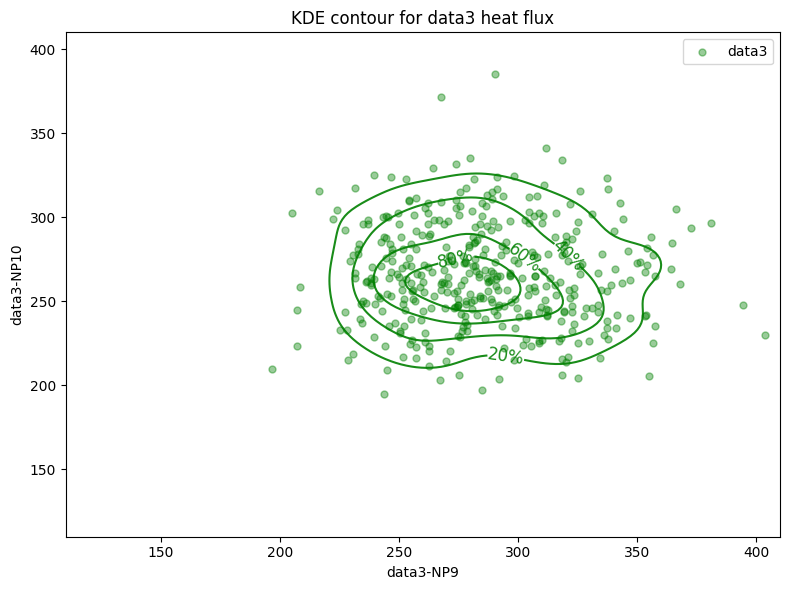

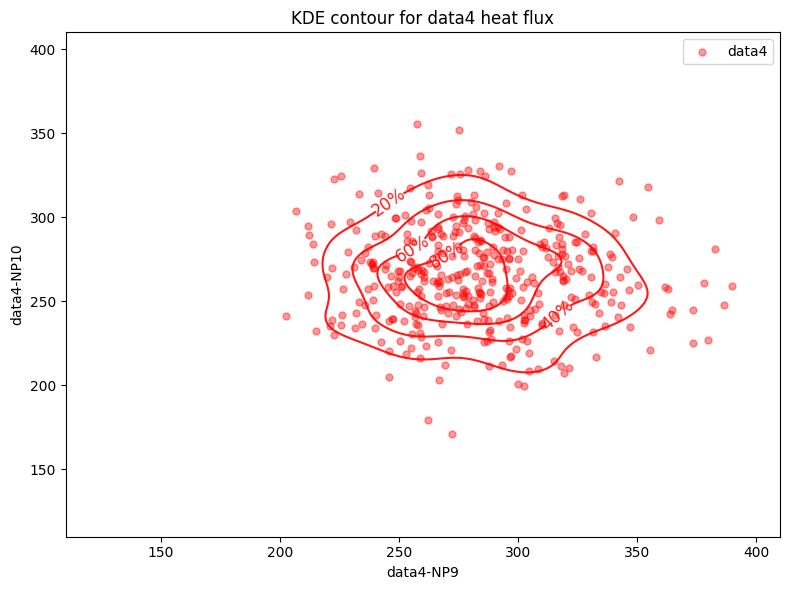

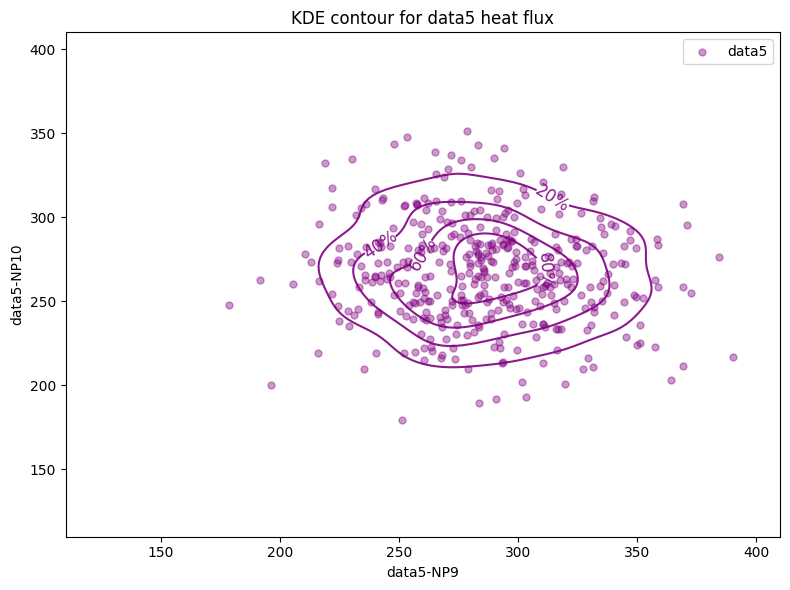

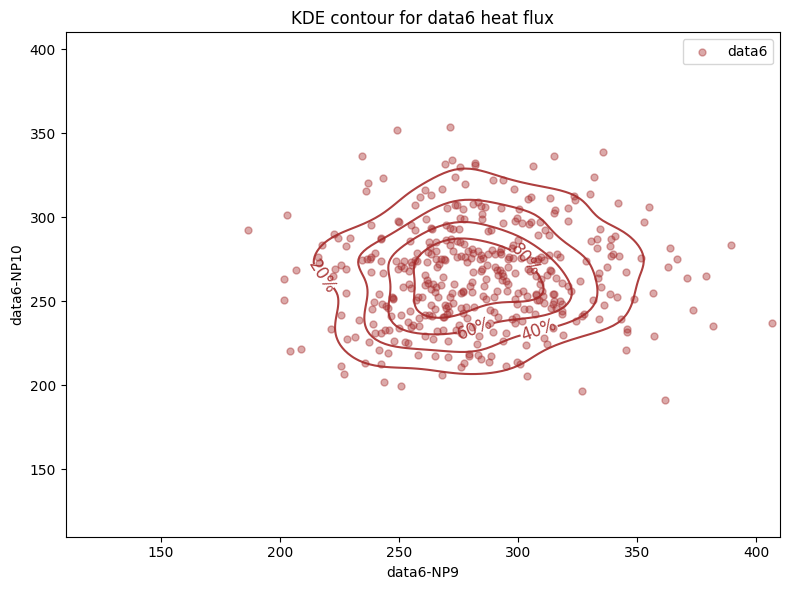

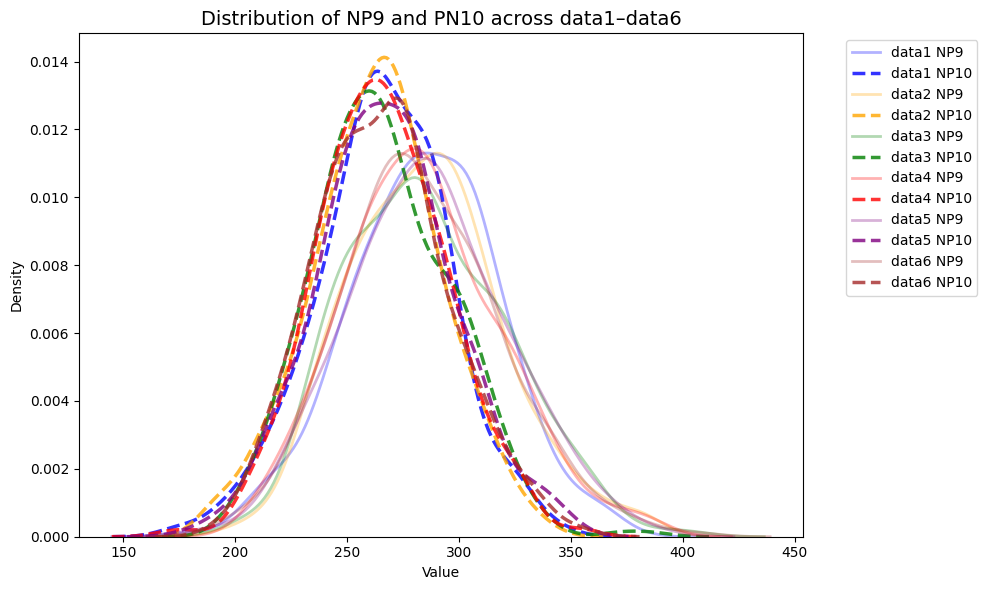

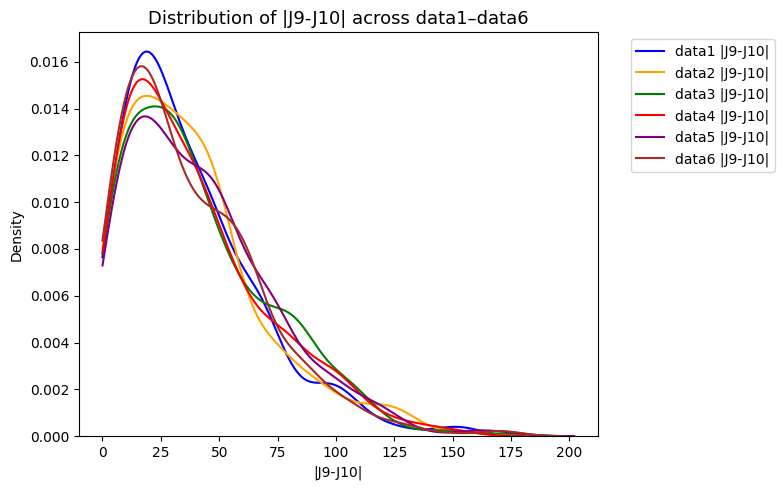

     pairing_num  FDR_distance
221          222     20.517784
114          115      9.534376
151          152      5.476371
20            21      5.204103
27            28      4.542528
..           ...           ...
245          246      0.000479
338          339      0.000423
7              8      0.000389
355          356      0.000039
55            56      0.000007

[400 rows x 2 columns]


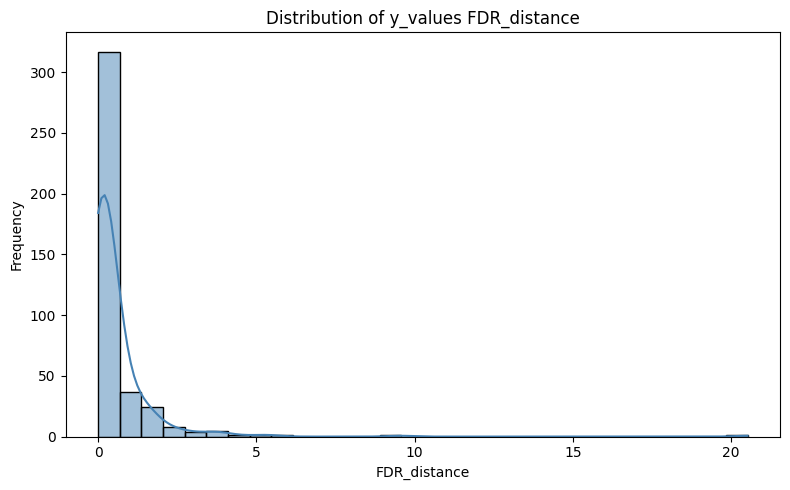

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets = [hf1, hf2, hf3, hf4, hf5, hf6]

labels = [f"data{i}" for i in range(1, 7)]
base_colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

for df, label, base_color in zip(datasets, labels, base_colors):
    fig=plt.figure(figsize=(8, 6))
    x = df.iloc[:, 8].values
    y = df.iloc[:, 9].values

    # Scatter points
    plt.scatter(x, y, s=25, alpha=0.4, color=base_color, label=f'{label}')

    # --- Compute KDE manually so we can label contours ---
    kde = gaussian_kde(np.vstack([x, y]))
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    # Create grid
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z_scaled = Z / Z.max() * 100  # 0–100%
    CS = plt.contour(X, Y, Z_scaled, levels=5, colors=[base_color], linewidths=1.5, alpha=0.9)
    plt.clabel(CS, inline=True, fontsize=12, fmt='%.0f%%')  # shows % of max density
    # --- Draw and label contours ---
    #CS = plt.contour(X, Y, Z, levels=5, colors=[base_color], linewidths=1.5, alpha=0.9)
    #plt.clabel(CS, inline=True, fontsize=8, fmt='%1.3f')  # Label with density values

    plt.xlabel(f'{label}-NP9')
    plt.ylabel(f'{label}-NP10')
    plt.xlim((110,410))
    plt.ylim((110,410))
    plt.legend()
    plt.title(f'KDE contour for {label} heat flux')
    plt.tight_layout()
    plt.show()
    fig.savefig(f"Heat_flux_{label}.pdf", format="pdf")


fig=plt.figure(figsize=(10, 6))
for df, label, base_color in zip(datasets, labels, base_colors):
    # lighter shade for column 9
    sns.kdeplot(df.iloc[:, 8],clip=(0, None), label=f'{label} NP9', color=base_color, alpha=0.3, linewidth=2)
    # darker shade for column 10
    sns.kdeplot(df.iloc[:, 9], label=f'{label} NP10', color=base_color, alpha=0.8, linewidth=2.5, linestyle='--')

plt.title('Distribution of NP9 and PN10 across data1–data6', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
fig.savefig(f"Heat_flux_distribution.pdf", format="pdf")

# Compute the sum of column 9 and 10 for each dataframe
# (Python is 0-indexed, so column 9 → index 8, column 10 → index 9)
output = pd.DataFrame({
    f"col{i+1}": np.sqrt((df.iloc[:, 8] - df.iloc[:, 9])**2)
    for i, df in enumerate(datasets)
})

# Plot KDE distributions for all (J9-J10)^2
fig=plt.figure(figsize=(8, 5))
for i, (label, base_color) in enumerate(zip(labels, base_colors)):
    sns.kdeplot(output[f"col{i+1}"],clip=(0, None), label=f'{label} |J9-J10|', color=base_color, fill=False)

plt.title('Distribution of |J9-J10| across data1–data6', fontsize=13)
plt.xlabel('|J9-J10|')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
fig.savefig(f"Heat_flux_difference.pdf", format="pdf")

# Compare first 3 columns (0,1,2) with next 3 columns (3,4,5)
left = output.iloc[:, 0:3]
right = output.iloc[:, 3:6]

# Compute mean and variance per row for each 3D group
mu_A = output.iloc[:, 0:3].mean(axis=1)
mu_B = output.iloc[:, 3:6].mean(axis=1)
var_A = output.iloc[:, 0:3].var(axis=1, ddof=1)
var_B = output.iloc[:, 3:6].var(axis=1, ddof=1)

# Compute Fisher’s Discriminant Ratio (FDR) for each row 
output["FDR_distance"] = (mu_A - mu_B) ** 2 / (var_A + var_B + 1e-8)

# Also compute centroid (mean) distance per row for reference
output["centroid_distance"] = np.sqrt((mu_A - mu_B) ** 2)

# 1. Combine
combined = pd.concat([df1["pairing_num"],
                      #output["centroid_distance"],
                      output["FDR_distance"]], axis=1)

# 2. Sort by FDR_distance
combined_sorted = combined.sort_values(by="FDR_distance", ascending=False)

# 3. Print
print(combined_sorted)

# Extract FDR_distance column and round to 3 decimal places
y_values = output["FDR_distance"]

# Plot the distribution of y
fig = plt.figure(figsize=(8, 5))
sns.histplot(y_values, kde=True, bins=30, color='steelblue')

plt.title(f"Distribution of y_values FDR_distance")
plt.xlabel("FDR_distance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
fig.savefig(f"Heat_flux_FDR_distance.pdf", format="pdf")

y_values_rounded = y_values.round(3)

# Convert to DataFrame to save as CSV
y_df = pd.DataFrame({"FDR_distance": y_values_rounded})

# Save to CSV
y_df.to_csv("round2_y_values.csv", index=False)
combined_sorted.to_csv("round2_y_values_sorted.csv", index=False)

In [4]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
#!pip install botorch
#!pip install ax-platform
#!pip install botorch gpytorch
#!pip install seaborn
#!git clone https://github.com/uber-research/TuRBO.git
#cd TuRBO
#!pip install -e .   # installs the library in editable mode
#import turbo  # if that’s the module name inside the repo
#print("TuRBO installed successfully")

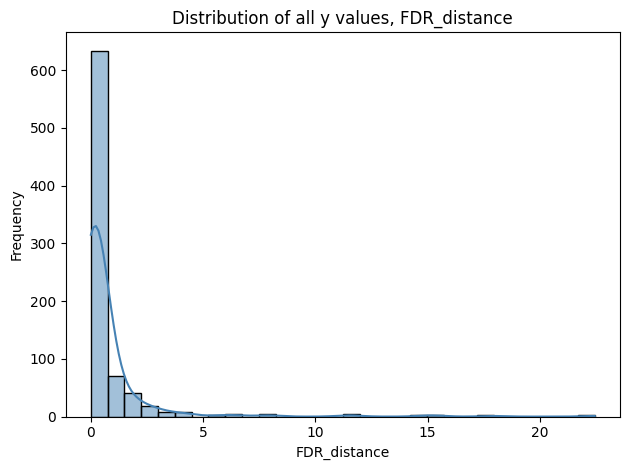

Original Y range: [0.0000, 22.4500]
TuRBO Batch Optimization with Warm Start

1. Loading 800 total points...
   X normalized to [0.0000, 1.0000]
   Y transformed: mean=0.0000, std=1.0000
   Best Y value: 10.0594

2. Generating 40 batches of 10 candidates...
Generated batch 1/40 (TR length: 0.8000)
Generated batch 2/40 (TR length: 0.8000)
Generated batch 3/40 (TR length: 0.8000)
Generated batch 4/40 (TR length: 0.8000)
Generated batch 5/40 (TR length: 0.8000)
Generated batch 6/40 (TR length: 0.8000)
Generated batch 7/40 (TR length: 0.8000)
Generated batch 8/40 (TR length: 0.8000)
Generated batch 9/40 (TR length: 0.8000)
Generated batch 10/40 (TR length: 0.8000)
Generated batch 11/40 (TR length: 0.8000)
Generated batch 12/40 (TR length: 0.8000)
Generated batch 13/40 (TR length: 0.8000)
Generated batch 14/40 (TR length: 0.8000)
Generated batch 15/40 (TR length: 0.8000)
Generated batch 16/40 (TR length: 0.8000)
Generated batch 17/40 (TR length: 0.8000)
Generated batch 18/40 (TR length: 0.8

In [7]:
import torch
import numpy as np
from torch.quasirandom import SobolEngine
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.utils.transforms import normalize, unnormalize, standardize
import warnings
warnings.filterwarnings('ignore')

def set_random_seed(seed=42):
    """
    Set random seeds for reproducibility across NumPy, PyTorch, and Python's random.
    
    Args:
        seed: Random seed value
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # For deterministic behavior (may impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class TuRBOBatch:
    """
    Trust Region Bayesian Optimization with batch candidate generation.
    Based on the TuRBO algorithm (Eriksson et al., 2019).
    """
    
    def __init__(
        self,
        dim,
        batch_size=10,
        n_trust_regions=1,
        length_min=0.5**7,
        length_max=1.6,
        length_init=0.8,
        success_tolerance=3,
        failure_tolerance=5,
        use_log_transform=False,
        dtype=torch.double,
        device='cpu',
        seed=None
    ):
        """
        Initialize TuRBO optimizer.
        
        Args:
            dim: Problem dimensionality
            batch_size: Number of points to generate per batch
            n_trust_regions: Number of independent trust regions
            length_min: Minimum trust region length
            length_max: Maximum trust region length
            length_init: Initial trust region length
            success_tolerance: Successes before expanding trust region
            failure_tolerance: Failures before shrinking trust region
            use_log_transform: Whether to log-transform Y values
            dtype: PyTorch data type
            device: PyTorch device
        """
        self.dim = dim
        self.batch_size = batch_size
        self.n_trust_regions = n_trust_regions
        self.length_min = length_min
        self.length_max = length_max
        self.length_init = length_init
        self.success_tolerance = success_tolerance
        self.failure_tolerance = failure_tolerance
        self.use_log_transform = use_log_transform
        self.dtype = dtype
        self.device = device
        self.seed = seed

        # Set random seed if provided
        if seed is not None:
            set_random_seed(seed)

        # Initialize trust region states
        self.reset_trust_regions()
        
        # Bounds (will be set from data)
        self.bounds = None
        
    def reset_trust_regions(self):
        """Reset trust region parameters."""
        self.length = [self.length_init] * self.n_trust_regions
        self.success_counter = [0] * self.n_trust_regions
        self.failure_counter = [0] * self.n_trust_regions
        self.best_value = [float('-inf')] * self.n_trust_regions
        self.center = [None] * self.n_trust_regions
        
    def load_warmstart(self, X_init, Y_init):
        """
        Load warm-start points with normalization and optional Y transformation.
        
        Args:
            X_init: (n_init, dim) array of initial input points
            Y_init: (n_init, 1) or (n_init,) array of initial observations
            
        Returns:
            X_normalized: Normalized X in [0, 1]^d
            Y_transformed: Standardized (and optionally log-transformed) Y
        """
        # Convert to torch tensors
        X = torch.tensor(X_init, dtype=self.dtype, device=self.device)
        Y = torch.tensor(Y_init, dtype=self.dtype, device=self.device)
        
        if Y.ndim == 1:
            Y = Y.unsqueeze(-1)
            
        # Store original bounds
        self.bounds = torch.stack([X.min(dim=0)[0], X.max(dim=0)[0]])
        
        # Normalize X to [0, 1]^d
        X_normalized = normalize(X, self.bounds)
        
        # Optional log transform for Y
        if self.use_log_transform:
            # Ensure all Y values are positive
            if (Y <= 0).any():
                print("Warning: Non-positive Y values detected. Adding offset for log transform.")
                Y = Y - Y.min() + 1e-6
            Y_log = torch.log(Y)
            Y_transformed = standardize(Y_log)
        else:
            Y_transformed = standardize(Y)
            
        # Initialize trust region centers
        best_idx = Y_transformed.argmax()
        for tr in range(self.n_trust_regions):
            self.center[tr] = X_normalized[best_idx].clone()
            self.best_value[tr] = Y_transformed[best_idx].item()
            
        return X_normalized, Y_transformed
    
    def _create_tr_bounds(self, tr_idx):
        """Create bounds for trust region."""
        center = self.center[tr_idx]
        length = self.length[tr_idx]
        
        lb = torch.clamp(center - length / 2.0, 0.0, 1.0)
        ub = torch.clamp(center + length / 2.0, 0.0, 1.0)
        
        return torch.stack([lb, ub])
    
    def _update_trust_region(self, tr_idx, new_y, new_x):
        """Update trust region based on new observation."""
        # Check if we improved
        if new_y > self.best_value[tr_idx]:
            self.success_counter[tr_idx] += 1
            self.failure_counter[tr_idx] = 0
            self.best_value[tr_idx] = new_y
            self.center[tr_idx] = new_x.clone()
        else:
            self.success_counter[tr_idx] = 0
            self.failure_counter[tr_idx] += 1
            
        # Expand trust region
        if self.success_counter[tr_idx] >= self.success_tolerance:
            self.length[tr_idx] = min(2.0 * self.length[tr_idx], self.length_max)
            self.success_counter[tr_idx] = 0
            
        # Shrink trust region
        if self.failure_counter[tr_idx] >= self.failure_tolerance:
            self.length[tr_idx] = max(0.5 * self.length[tr_idx], self.length_min)
            self.failure_counter[tr_idx] = 0
            
    def generate_batch(self, X_train, Y_train, tr_idx=0):
        """
        Generate a batch of candidate points using BO within trust region.
        
        Args:
            X_train: (n, dim) normalized training inputs
            Y_train: (n, 1) transformed training outputs
            tr_idx: Trust region index
            
        Returns:
            X_next: (batch_size, dim) normalized candidate points
        """
        # Fit GP model
        model = SingleTaskGP(X_train, Y_train)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
        
        # Create trust region bounds
        tr_bounds = self._create_tr_bounds(tr_idx)
        
        # Create acquisition function
        qEI = qExpectedImprovement(model, best_f=Y_train.max())
        
        # Optimize acquisition function
        candidates, _ = optimize_acqf(
            acq_function=qEI,
            bounds=tr_bounds,
            q=self.batch_size,
            num_restarts=10,
            raw_samples=512,
            options={"batch_limit": 5, "maxiter": 200},
        )
        
        return candidates
    
    def generate_all_batches(self, X_train, Y_train, n_batches=1):
        """
        Generate multiple batches of candidates.
        
        Args:
            X_train: (n, dim) normalized training inputs
            Y_train: (n, 1) transformed training outputs
            n_batches: Number of batches to generate
            
        Returns:
            all_candidates: (n_batches * batch_size, dim) normalized candidates
        """
        all_candidates = []
        
        for batch_idx in range(n_batches):
            # Select trust region (can implement more sophisticated selection)
            tr_idx = batch_idx % self.n_trust_regions
            
            # Generate batch
            candidates = self.generate_batch(X_train, Y_train, tr_idx)
            all_candidates.append(candidates)
            
            print(f"Generated batch {batch_idx + 1}/{n_batches} "
                  f"(TR length: {self.length[tr_idx]:.4f})")
        
        return torch.cat(all_candidates, dim=0)
    
    def denormalize_candidates(self, X_normalized):
        """
        Convert normalized candidates back to original space.
        
        Args:
            X_normalized: (n, dim) candidates in [0, 1]^d
            
        Returns:
            X_original: (n, dim) candidates in original space
        """
        if self.bounds is None:
            raise ValueError("Must call load_warmstart first to set bounds")
            
        return unnormalize(X_normalized, self.bounds)
    
    def inverse_transform_y(self, Y_transformed):
        """
        Inverse transform Y values (if log transform was used).
        Note: This is approximate due to standardization.
        """
        if self.use_log_transform:
            return torch.exp(Y_transformed)
        return Y_transformed


# Example usage
if __name__ == "__main__":
    # Simulate 400 warm-start points
    dim = 28
    n_total = 800
    RANDOM_SEED = 42  # Change this value for different random runs
    set_random_seed(RANDOM_SEED)
    # Generate synthetic data (replace with your actual data)
    #X_init = np.random.uniform(0, 10, (n_warmstart, dim))
    #Y_init = -np.sum((X_init - 5)**2, axis=1) + np.random.randn(n_warmstart) * 0.1
    # Convert to NumPy arrays if they're pandas objects
    X_init_df = pd.read_csv('../PNN_round2_TuRBO/round1_x_values.csv')
    X_init = X_init_df.values  # Convert to NumPy array
    Y_init_df = pd.read_csv('../PNN_round2_TuRBO/round1_y_values.csv')
    Y_init = Y_init_df['FDR_distance'].values  # Or use .iloc[:, 0] for first column
    
    X_round2_df = pd.read_csv('round2_x_values.csv')
    X_round2 = X_init_df.values  # Convert to NumPy array
    Y_round2_df = pd.read_csv('round2_y_values.csv')
    Y_round2 = Y_init_df['FDR_distance'].values  # Or use .iloc[:, 0] for first column

    X_all = np.vstack([X_init, X_round2])
    Y_all = np.concatenate([Y_init, Y_round2])

    # Plot the distribution of y
    sns.histplot(Y_all, kde=True, bins=30, color='steelblue')
    
    plt.title(f"Distribution of all y values, FDR_distance")
    plt.xlabel("FDR_distance")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print(f"Original Y range: [{Y_init.min():.4f}, {Y_init.max():.4f}]")
    #print(f"Log-scaled Y range: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]")
    
    print("=" * 70)
    print("TuRBO Batch Optimization with Warm Start")
    print("=" * 70)
    
    # Initialize TuRBO
    turbo = TuRBOBatch(
        dim=dim,
        batch_size=10,  # Generate 10 points per batch
        n_trust_regions=1,
        use_log_transform=False,  # Set True if Y values are positive and span orders of magnitude
        dtype=torch.double,
        device='cpu',
        seed=RANDOM_SEED  # Pass seed for reproducibility
)
    
    # Step 1: Load warm-start data with normalization
    print(f"\n1. Loading {n_total} total points...")
    X_train, Y_train = turbo.load_warmstart(X_all, Y_all)
    print(f"   X normalized to [{X_train.min():.4f}, {X_train.max():.4f}]")
    print(f"   Y transformed: mean={Y_train.mean():.4f}, std={Y_train.std():.4f}")
    print(f"   Best Y value: {Y_train.max():.4f}")
    
    # Step 2: Generate 400 new candidate points in batches of 10
    n_batches = 40  # 40 batches × 10 points = 400 candidates
    print(f"\n2. Generating {n_batches} batches of {turbo.batch_size} candidates...")
    X_candidates_normalized = turbo.generate_all_batches(X_train, Y_train, n_batches)
    
    # Step 3: Denormalize candidates back to original space
    print(f"\n3. Denormalizing {len(X_candidates_normalized)} candidates...")
    X_candidates = turbo.denormalize_candidates(X_candidates_normalized)
    
    print(f"\nCandidates shape: {X_candidates.shape}")
    print(f"Candidates range: [{X_candidates.min():.4f}, {X_candidates.max():.4f}]")
    print("\nFirst 5 candidates:")
    print(X_candidates[:5].numpy())
    
    # Optional: Update trust region with new observations
    print("\n4. Example trust region update (after evaluating candidates)...")
    for i in range(min(3, len(X_candidates))):
        # Simulate evaluation (replace with actual objective function)
        y_new = torch.randn(1, 1) * 0.1 + Y_train.max()
        turbo._update_trust_region(0, y_new.item(), X_candidates_normalized[i])
        print(f"   After evaluation {i+1}: TR length = {turbo.length[0]:.4f}")
    
    # Step 5: Save candidates to CSV
    print("\n5. Saving candidates to CSV...")
    import pandas as pd
    
    # Convert to numpy and create DataFrame
    X_candidates_np = X_candidates.cpu().numpy()
    column_names = [f'x{i+1}' for i in range(dim)]
    df_candidates = pd.DataFrame(X_candidates_np, columns=column_names)
    
    # Save to CSV
    df_candidates.to_csv('X_candidates_next400.csv', index=False, float_format="%.3f")
    print("Next 400 candidate points saved to X_candidates_next400.csv")
    
    print("\n" + "=" * 70)
    print("Optimization complete!")
    print("=" * 70)